In [ ]:
!pip install nltk

In [61]:
# Essential Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import nltk
import string
from nltk.corpus import stopwords

In [6]:
df = pd.read_csv('spam.csv', encoding='latin1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### **Data Cleaning**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)
df.rename(columns={'v1':'target','v2':'text'}, inplace=True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df.drop_duplicates(keep='first', inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(5169, 2)

### **EDA**

In [12]:
df['target'].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

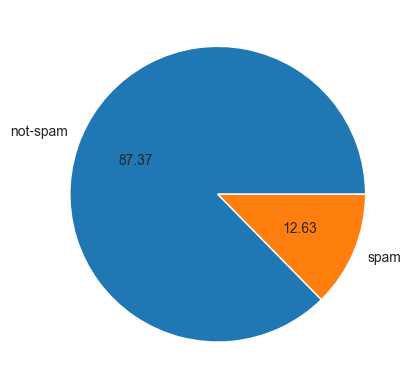

In [13]:
plt.pie(df['target'].value_counts(), labels=['not-spam','spam'], autopct='%0.2f')
plt.show()

In [14]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dellu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dellu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
df['num_of_all_characters'] = df['text'].apply(lambda x: len(x))# for all characters including special characters also
df['num_of_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_of_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_of_all_characters,num_of_words,num_of_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])
df.head()

,target,text,num_of_all_characters,num_of_words,num_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [17]:
df[['num_of_all_characters','num_of_words','num_of_sentences']].describe()

,num_of_all_characters,num_of_words,num_of_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [18]:
df[df['target']==0][['num_of_all_characters', 'num_of_words', 'num_of_sentences']].describe()

,num_of_all_characters,num_of_words,num_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [19]:
df[df['target']==1][['num_of_all_characters', 'num_of_words', 'num_of_sentences']].describe()

,num_of_all_characters,num_of_words,num_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_of_all_characters', ylabel='Count'>

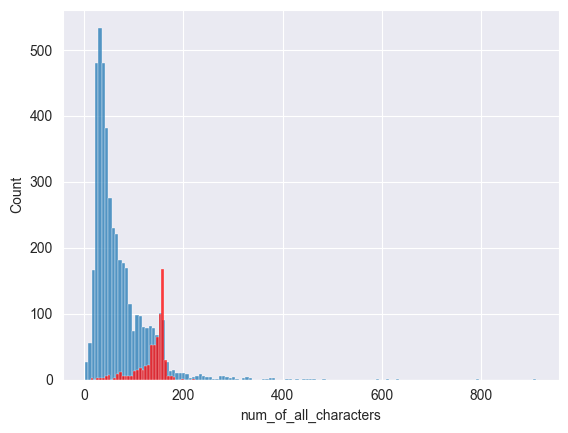

In [20]:
sns.histplot(df[df['target']==0]['num_of_all_characters'])
sns.histplot(df[df['target']==1]['num_of_all_characters'],color='red')


<Axes: xlabel='num_of_words', ylabel='Count'>

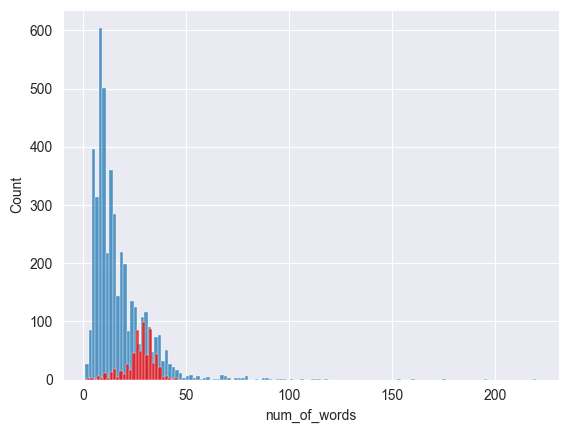

In [21]:
sns.histplot(df[df['target']==0]['num_of_words'])
sns.histplot(df[df['target']==1]['num_of_words'],color='red')


<Axes: xlabel='num_of_sentences', ylabel='Count'>

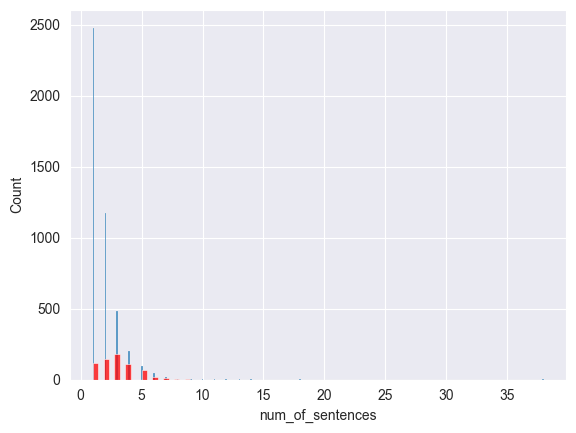

In [22]:
sns.histplot(df[df['target']==0]['num_of_sentences'])
sns.histplot(df[df['target']==1]['num_of_sentences'],color='red')


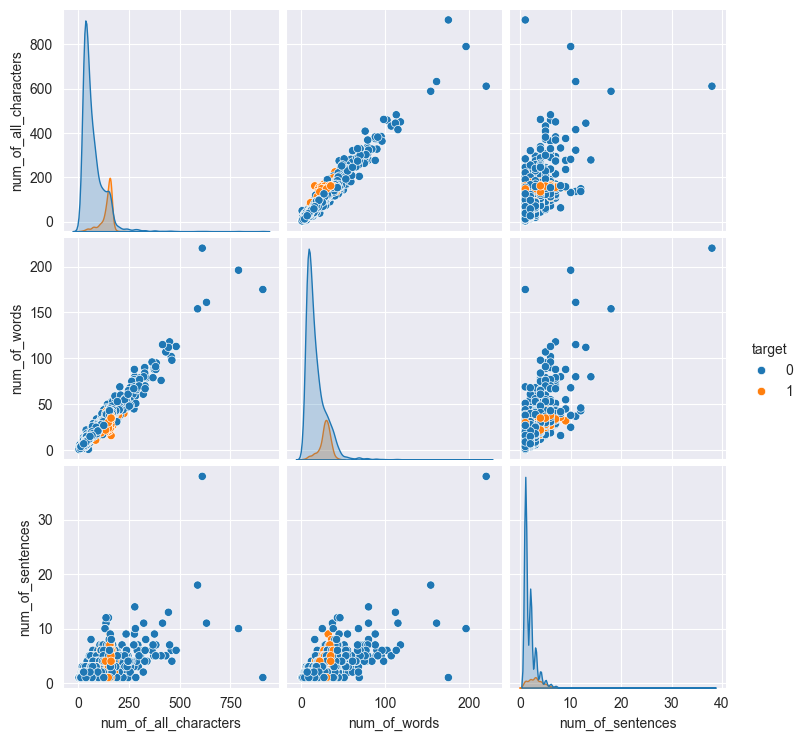

In [23]:
sns.pairplot(df, hue='target')

In [24]:
df.groupby('target')['num_of_all_characters'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
1,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


In [25]:
print(df.groupby('target')['num_of_all_characters'].mean())
print(df.groupby('target')['num_of_all_characters'].median())

target
0     70.459256
1    137.891271
Name: num_of_all_characters, dtype: float64
target
0     52.0
1    149.0
Name: num_of_all_characters, dtype: float64


<Axes: >

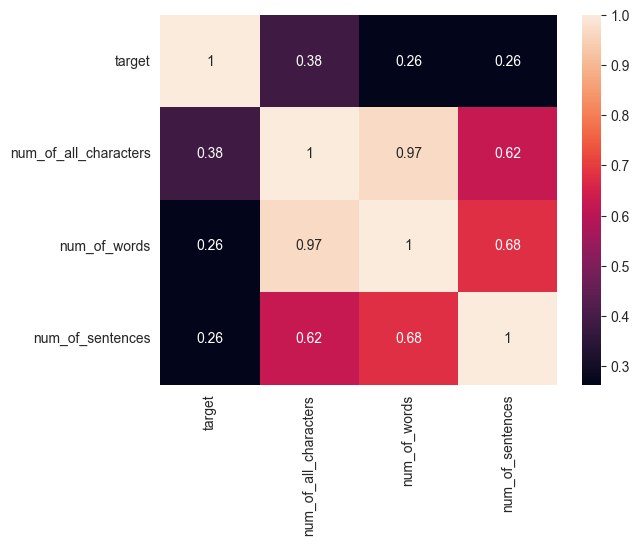

In [26]:
sns.heatmap(df[['target','num_of_all_characters','num_of_words','num_of_sentences']].corr(),annot=True)

### **Data Preprocessing**
For textual data : <br>
1. Lower case
2. Tokenization
3. Remove special characters
4. Remove stop words and punctuations
5. Stemming

In [28]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [29]:
def preprocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [32]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [33]:
preprocessing('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [34]:
df['preprocessed_text'] = df['text'].apply(preprocessing)
df.head()

,target,text,num_of_all_characters,num_of_words,num_of_sentences,preprocessed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [36]:
from wordcloud import WordCloud
wc = WordCloud(height=500, width=500, min_font_size=10, background_color='white')

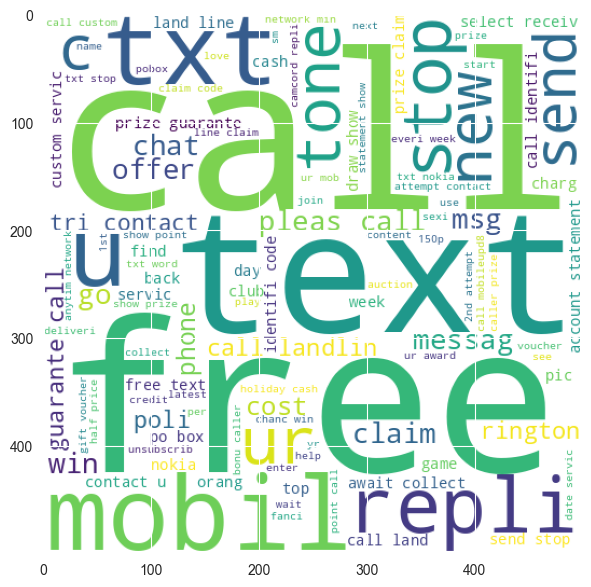

In [37]:
spam = wc.generate(df[df['target']==1]['preprocessed_text'].str.cat(sep=""))
plt.figure(figsize=(7,7))
plt.imshow(spam)

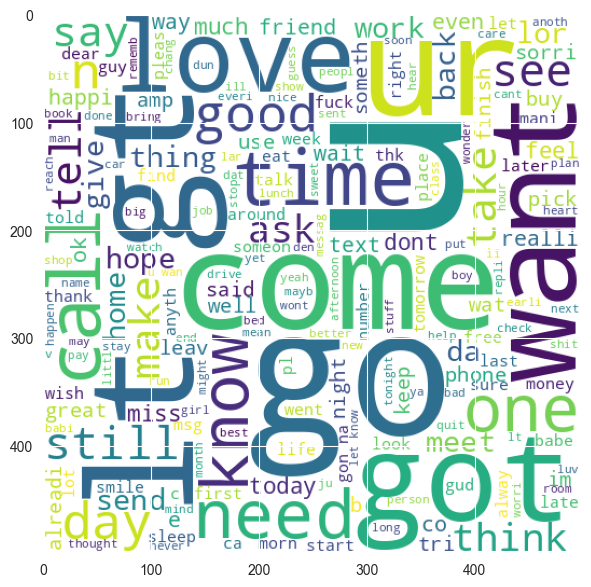

In [38]:
non_spam = wc.generate(df[df['target']==0]['preprocessed_text'].str.cat(sep=""))
plt.figure(figsize=(7,7))
plt.imshow(non_spam)

In [39]:
spam_corpus = []
for msg in df[df['target'] == 1]['preprocessed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)



In [40]:
len(spam_corpus)

9939

In [41]:
non_spam_corpus = []
for msg in df[df['target'] == 0]['preprocessed_text'].tolist():
    for word in msg.split():
        non_spam_corpus.append(word)



In [42]:
len(non_spam_corpus)

35404

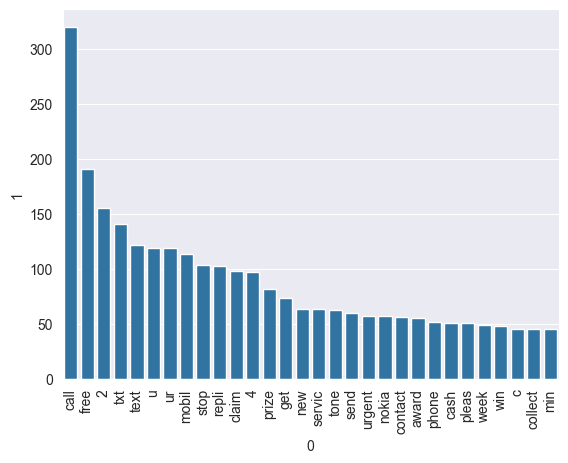

In [43]:
from collections import Counter
df_ = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=df_[0], y=df_[1])
plt.xticks(rotation='vertical')
plt.show()

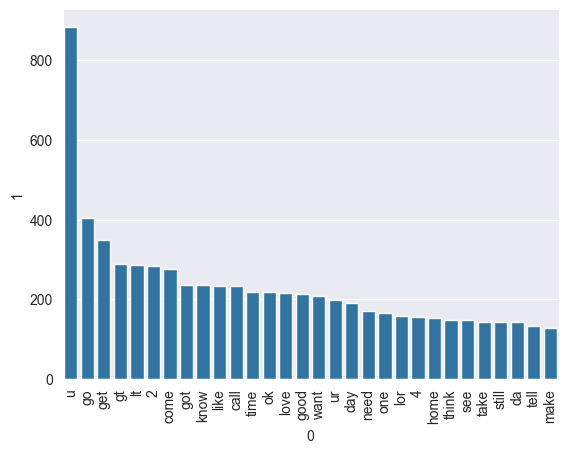

In [44]:
df_ = pd.DataFrame(Counter(non_spam_corpus).most_common(30))
sns.barplot(x=df_[0], y=df_[1])
plt.xticks(rotation='vertical')
plt.show()

### **Model Building**

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfid = TfidfVectorizer(max_features=3000)
x = tfid.fit_transform(df['preprocessed_text']).toarray()
y = df['target'].values

In [46]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [47]:
# Since Naive Bayes algorithm performs well on textual data
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier



In [48]:
from sklearn.metrics import accuracy_score,precision_score
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [49]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)

In [50]:
clfs = {
    'GNB': gnb,
    'MNB': mnb,
    'BNB': bnb,
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt
}

In [51]:
current_accuracy=[]
current_precision=[]
for name, clf in clfs.items():
    acc, prec = train_classifier(clf,x_train,y_train,x_test,y_test)
    print('For Model ', name)
    print('Accuracy:',acc)
    print('Precision:',prec)
    current_accuracy.append(acc)
    current_precision.append(prec)

For Model  GNB
Accuracy: 0.8636363636363636
Precision: 0.5083333333333333
For Model  MNB
Accuracy: 0.971953578336557
Precision: 0.9915254237288136
For Model  BNB
Accuracy: 0.9729206963249516
Precision: 0.9606299212598425
For Model  SVC
Accuracy: 0.97678916827853
Precision: 0.9548872180451128
For Model  KN
Accuracy: 0.913926499032882
Precision: 1.0
For Model  NB
Accuracy: 0.971953578336557
Precision: 0.9915254237288136
For Model  DT
Accuracy: 0.9342359767891683
Precision: 0.8130081300813008
For Model  LR
Accuracy: 0.9497098646034816
Precision: 0.872
For Model  RF
Accuracy: 0.9700193423597679
Precision: 0.9913793103448276
For Model  AdaBoost
Accuracy: 0.9148936170212766
Precision: 0.7938144329896907
For Model  BgC
Accuracy: 0.9593810444874274
Precision: 0.8601398601398601
For Model  ETC
Accuracy: 0.9748549323017408
Precision: 0.9612403100775194
For Model  GBDT
Accuracy: 0.9497098646034816
Precision: 0.9603960396039604


In [53]:
algo_performances = pd.DataFrame({'Algorithms':clfs.keys(),'Accuracy':current_accuracy, 'Precision':current_precision}).sort_values('Precision',ascending=False)
algo_performances

,Algorithms,Accuracy,Precision
4,KN,0.913926,1.000000
1,MNB,0.971954,0.991525
5,NB,0.971954,0.991525
8,RF,0.970019,0.991379
11,ETC,0.974855,0.961240
2,BNB,0.972921,0.960630
12,GBDT,0.949710,0.960396
3,SVC,0.976789,0.954887
7,LR,0.949710,0.872000
10,BgC,0.959381,0.860140


In [54]:
# Applying Voting Classifier
from sklearn.ensemble import VotingClassifier
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
svm = SVC(kernel='sigmoid', gamma=1.0, probability=True)
voting = VotingClassifier(estimators=[('Mnb',mnb),('SVM',svm),('ETC',etc)],voting='soft')



In [55]:
train_classifier(voting,x_train,y_train,x_test,y_test)

(0.9806576402321083, 0.9770992366412213)

In [57]:
# Applying stacking
from sklearn.ensemble import StackingClassifier
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
svm = SVC(kernel='sigmoid', gamma=1.0, probability=True)
estimator=[('Mnb',mnb),('SVM',svm),('ETC',etc)]
final_model = RandomForestClassifier(n_estimators=50, random_state=2)
stack = StackingClassifier(estimators=estimator,final_estimator=final_model)

# Model training
train_classifier(stack,x_train,y_train,x_test,y_test)


(0.9806576402321083, 0.9370629370629371)

In [60]:
import pickle
pickle.dump(tfid,open('vectorixer.pkl','wb'))
pickle.dump(voting,open('model.pkl','wb'))